## Import neccessary library

In [19]:
    import os
    from pathlib import Path

    import pandas as pd
    import numpy as np
    import seaborn as sns
    import matplotlib.pyplot as plt
    from scipy.stats import pearsonr
    from sklearn.model_selection import train_test_split


In [20]:
def find_file_upwards(filename, current_dir=None):
    if current_dir is None:
        current_dir = os.getcwd()
    while os.path.basename(current_dir) != "Machine_Learning":
        current_dir = os.path.dirname(current_dir)
    for root, dirs, files in os.walk(current_dir):
            if filename in files:
                return os.path.join(root, filename)
    raise FileNotFoundError(
        f"❌ Không tìm thấy file '{filename}'."
    )

csv_path = find_file_upwards("data-ori.csv")
df = pd.read_csv(csv_path)
df.head()

,HAEMATOCRIT,HAEMOGLOBINS,ERYTHROCYTE,LEUCOCYTE,THROMBOCYTE,MCH,MCHC,MCV,AGE,SEX,SOURCE
0,35.1,11.8,4.65,6.3,310,25.4,33.6,75.5,1,F,out
1,43.5,14.8,5.39,12.7,334,27.5,34.0,80.7,1,F,out
2,33.5,11.3,4.74,13.2,305,23.8,33.7,70.7,1,F,out
3,39.1,13.7,4.98,10.5,366,27.5,35.0,78.5,1,F,out
4,30.9,9.9,4.23,22.1,333,23.4,32.0,73.0,1,M,out


In [21]:
df.tail()

,HAEMATOCRIT,HAEMOGLOBINS,ERYTHROCYTE,LEUCOCYTE,THROMBOCYTE,MCH,MCHC,MCV,AGE,SEX,SOURCE
4407,32.8,10.4,3.49,8.1,72,29.8,31.7,94.0,92,F,in
4408,33.7,10.8,3.67,6.7,70,29.4,32.0,91.8,92,F,in
4409,33.2,11.2,3.47,7.2,235,32.3,33.7,95.7,93,F,out
4410,31.5,10.4,3.15,9.1,187,33.0,33.0,100.0,98,F,in
4411,33.5,10.9,3.44,5.8,275,31.7,32.5,97.4,99,F,out


## Sanity check of data

In [22]:
#SHAPE
df.shape

(4412, 11)

In [23]:
#info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4412 entries, 0 to 4411
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   HAEMATOCRIT   4412 non-null   float64
 1   HAEMOGLOBINS  4412 non-null   float64
 2   ERYTHROCYTE   4412 non-null   float64
 3   LEUCOCYTE     4412 non-null   float64
 4   THROMBOCYTE   4412 non-null   int64  
 5   MCH           4412 non-null   float64
 6   MCHC          4412 non-null   float64
 7   MCV           4412 non-null   float64
 8   AGE           4412 non-null   int64  
 9   SEX           4412 non-null   object 
 10  SOURCE        4412 non-null   object 
dtypes: float64(7), int64(2), object(2)
memory usage: 379.3+ KB


In [24]:
df.isnull().sum()

HAEMATOCRIT     0
HAEMOGLOBINS    0
ERYTHROCYTE     0
LEUCOCYTE       0
THROMBOCYTE     0
MCH             0
MCHC            0
MCV             0
AGE             0
SEX             0
SOURCE          0
dtype: int64

In [25]:
df.duplicated().sum()

np.int64(0)

In [26]:
for i in df.select_dtypes(include="object").columns:
    print(df[i].value_counts())
    print("***"*10)

SEX
M    2290
F    2122
Name: count, dtype: int64
******************************
SOURCE
out    2628
in     1784
Name: count, dtype: int64
******************************


## Exploratory Data Analysis

In [27]:
df.describe()

,HAEMATOCRIT,HAEMOGLOBINS,ERYTHROCYTE,LEUCOCYTE,THROMBOCYTE,MCH,MCHC,MCV,AGE
count,4412.000000,4412.000000,4412.000000,4412.000000,4412.000000,4412.000000,4412.000000,4412.000000,4412.000000
mean,38.197688,12.741727,4.541260,8.718608,257.524479,28.234701,33.343042,84.612942,46.626473
std,5.974784,2.079903,0.784091,5.049041,113.972365,2.672639,1.228664,6.859101,21.731218
min,13.700000,3.800000,1.480000,1.100000,8.000000,14.900000,26.000000,54.000000,1.000000
25%,34.375000,11.400000,4.040000,5.675000,188.000000,27.200000,32.700000,81.500000,29.000000
50%,38.600000,12.900000,4.570000,7.600000,256.000000,28.700000,33.400000,85.400000,47.000000
75%,42.500000,14.200000,5.050000,10.300000,321.000000,29.800000,34.100000,88.700000,64.000000
max,69.000000,18.900000,7.860000,76.600000,1183.000000,40.800000,39.000000,115.600000,99.000000


In [28]:
df.describe(include="object")


,SEX,SOURCE
count,4412,4412
unique,2,2
top,M,out
freq,2290,2628


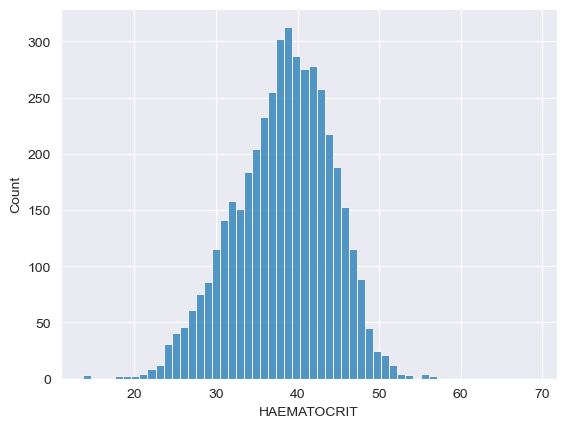

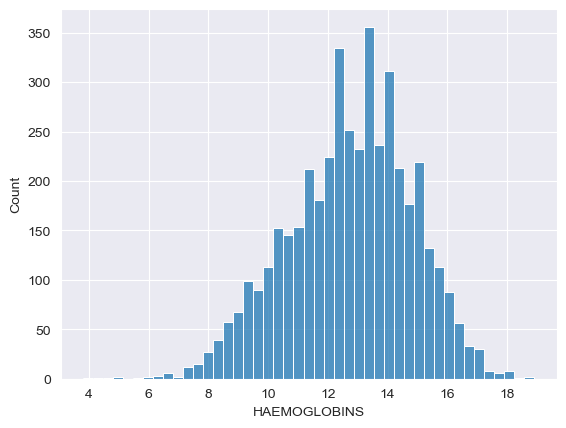

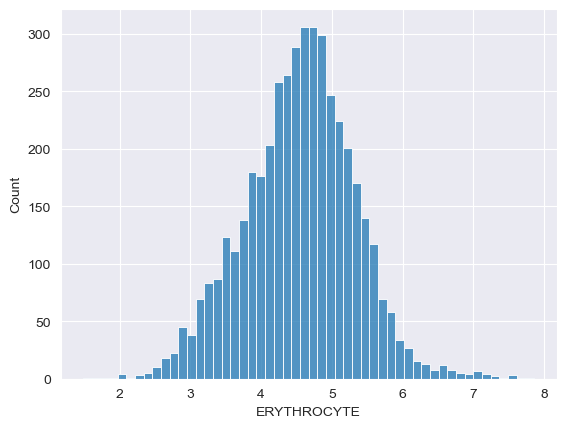

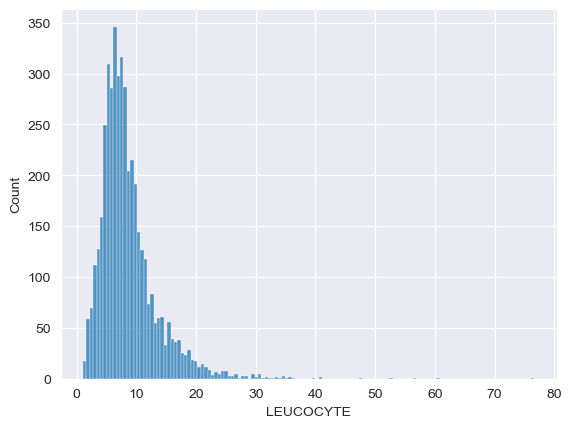

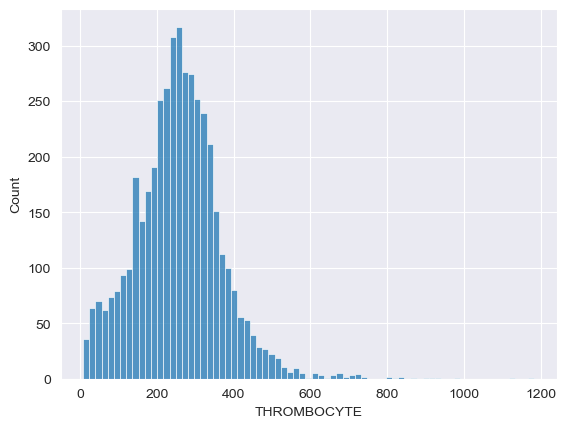

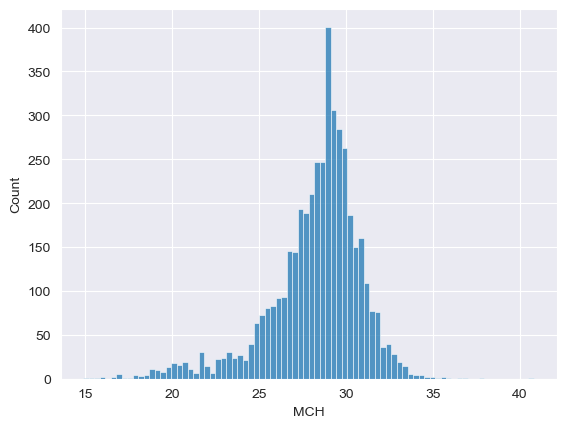

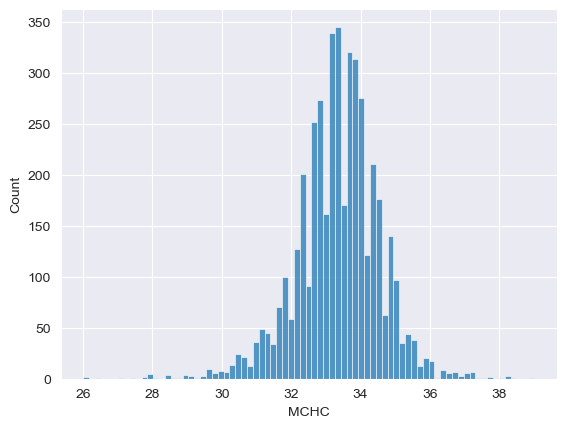

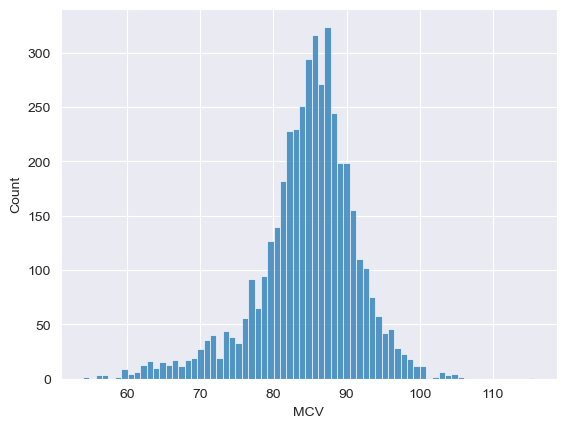

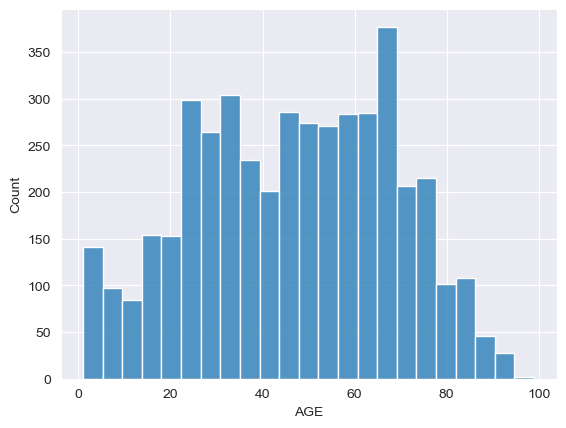

In [29]:
for i in df.select_dtypes(include="number").columns:
    sns.histplot(data=df, x=i)
    plt.show()

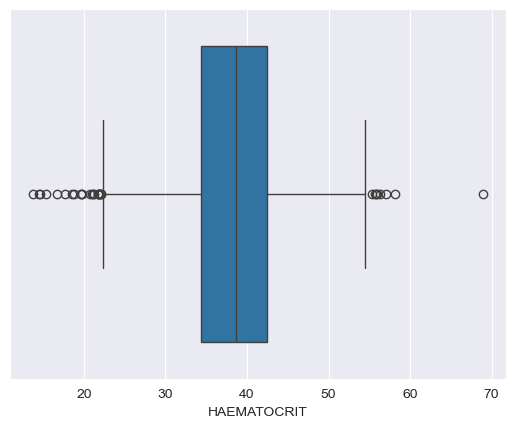

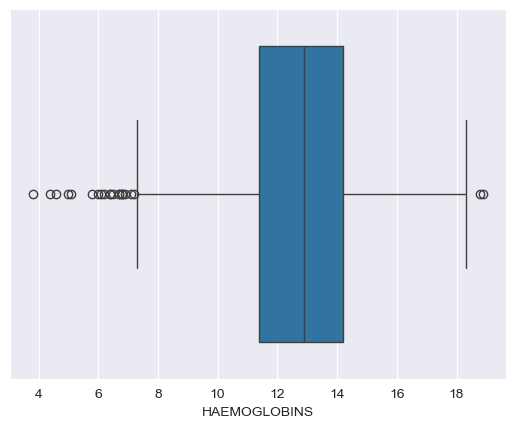

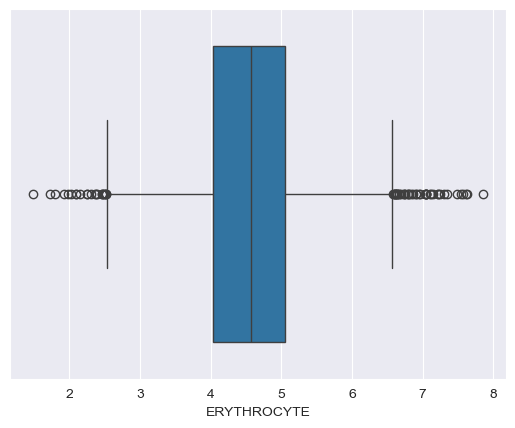

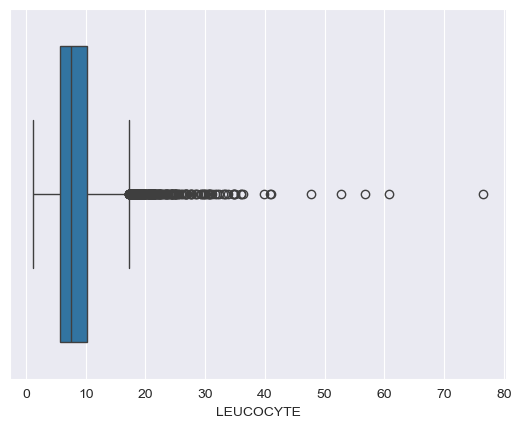

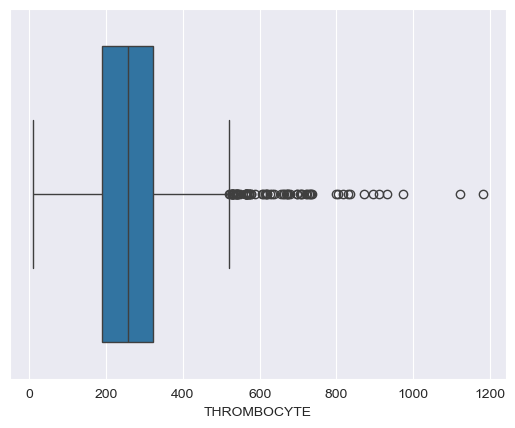

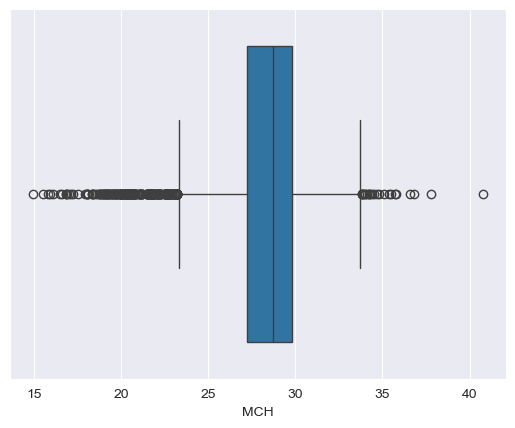

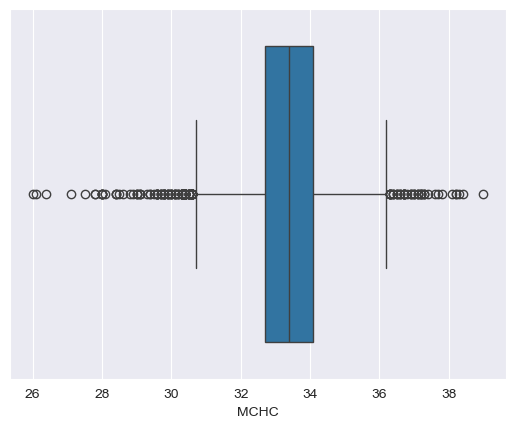

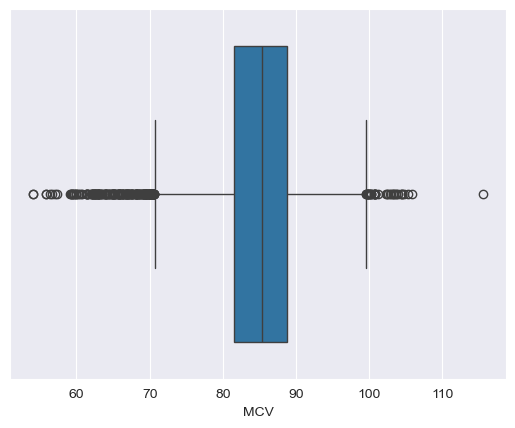

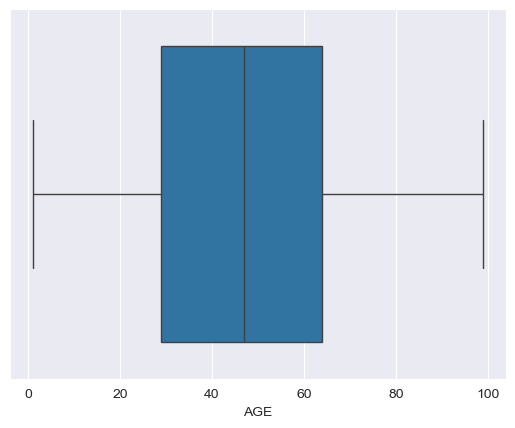

In [30]:
#Box-plot indentify outliers
for i in df.select_dtypes(include="number").columns:
    sns.boxplot(data=df, x=i)
    plt.show()

In [31]:
df.select_dtypes(include="number").columns

Index(['HAEMATOCRIT', 'HAEMOGLOBINS', 'ERYTHROCYTE', 'LEUCOCYTE',
       'THROMBOCYTE', 'MCH', 'MCHC', 'MCV', 'AGE'],
      dtype='object')

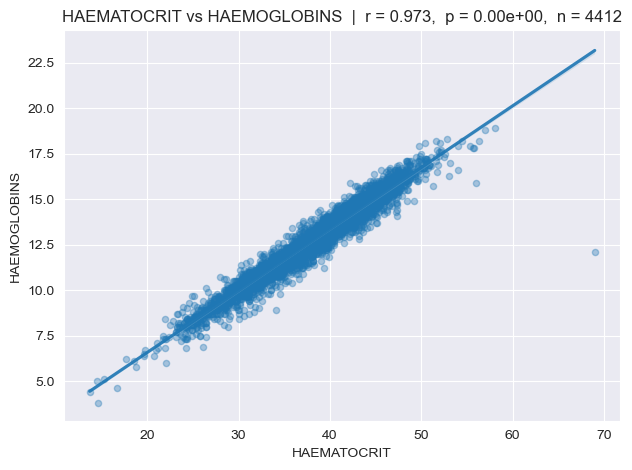

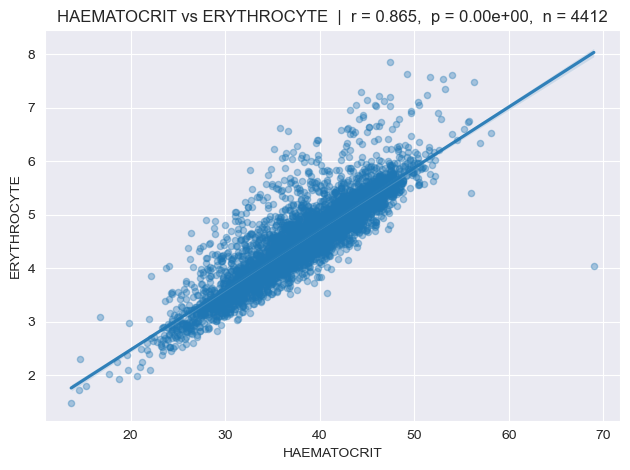

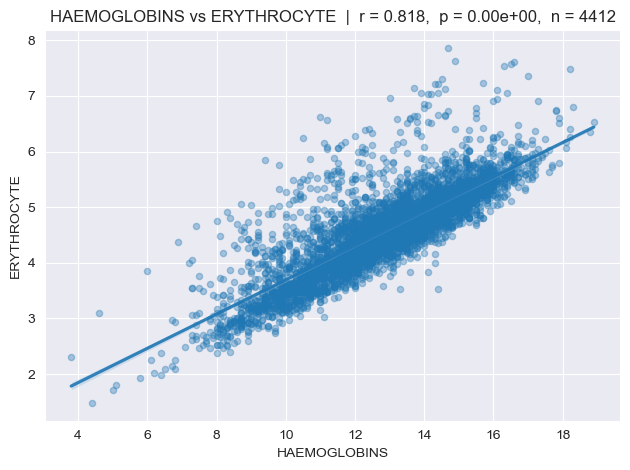

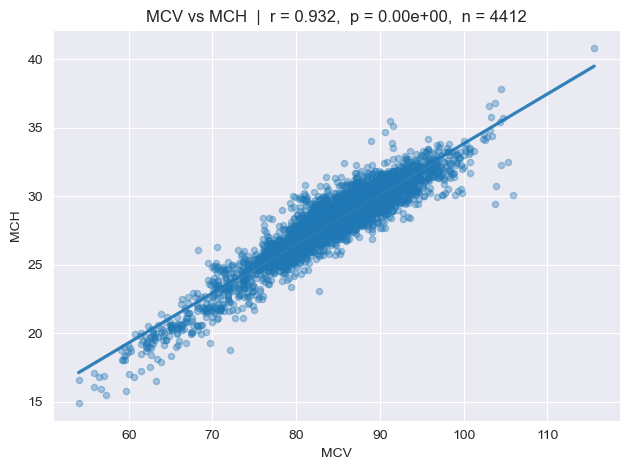

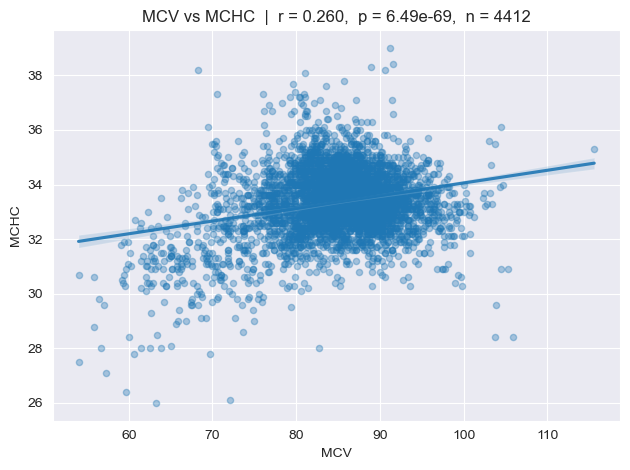

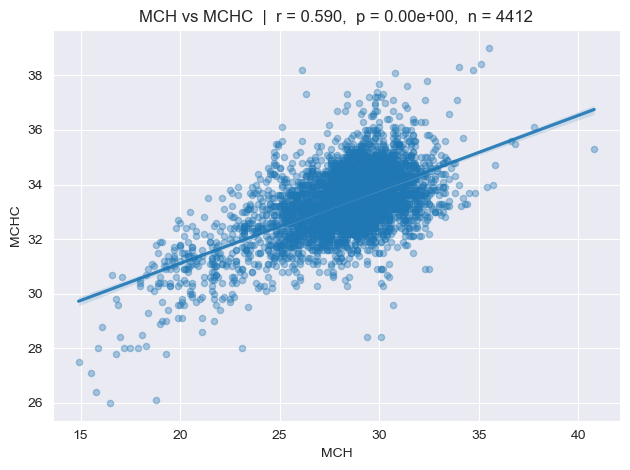

In [32]:
#scatter plot understand the relationship
pairs = [
    ("HAEMATOCRIT",  "HAEMOGLOBINS"),
    ("HAEMATOCRIT",  "ERYTHROCYTE"),
    ("HAEMOGLOBINS", "ERYTHROCYTE"),
    ("MCV", "MCH"),
    ("MCV", "MCHC"),
    ("MCH", "MCHC"),
]
for x, y in pairs:
    sub = df[[x, y]].dropna()
    r, p = pearsonr(sub[x], sub[y])

    ax = sns.regplot(data=sub, x=x, y=y, scatter_kws={"alpha":0.35, "s":20}, line_kws={"alpha":0.9})
    ax.set_title(f"{x} vs {y}  |  r = {r:.3f},  p = {p:.2e},  n = {len(sub)}")
    plt.tight_layout(); plt.show()


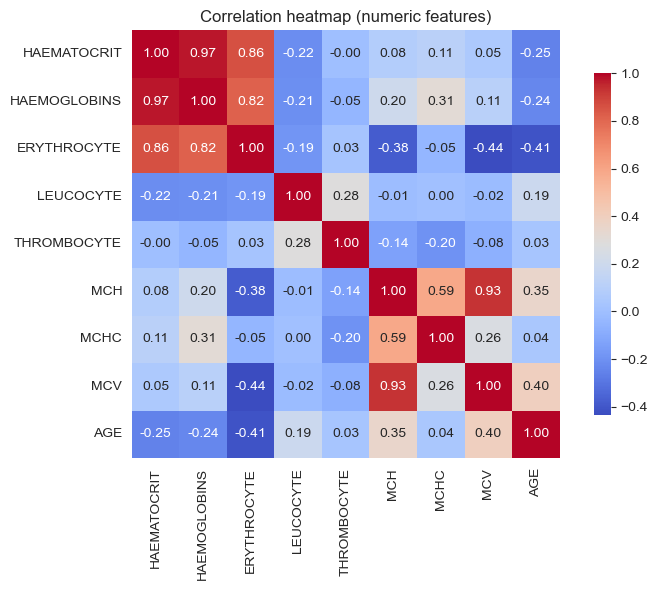

In [33]:
num_cols = df.select_dtypes(include="number").columns
corr = df[num_cols].corr(method="pearson")
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True, cbar_kws={"shrink": .8})
plt.title("Correlation heatmap (numeric features)"); plt.tight_layout(); plt.show()


## Check missing value

In [34]:
df.isnull().sum()

HAEMATOCRIT     0
HAEMOGLOBINS    0
ERYTHROCYTE     0
LEUCOCYTE       0
THROMBOCYTE     0
MCH             0
MCHC            0
MCV             0
AGE             0
SEX             0
SOURCE          0
dtype: int64

## Duplicates & Garbage value

In [35]:
df.drop_duplicates()

,HAEMATOCRIT,HAEMOGLOBINS,ERYTHROCYTE,LEUCOCYTE,THROMBOCYTE,MCH,MCHC,MCV,AGE,SEX,SOURCE
0,35.1,11.8,4.65,6.3,310,25.4,33.6,75.5,1,F,out
1,43.5,14.8,5.39,12.7,334,27.5,34.0,80.7,1,F,out
2,33.5,11.3,4.74,13.2,305,23.8,33.7,70.7,1,F,out
3,39.1,13.7,4.98,10.5,366,27.5,35.0,78.5,1,F,out
4,30.9,9.9,4.23,22.1,333,23.4,32.0,73.0,1,M,out
...,...,...,...,...,...,...,...,...,...,...,...
4407,32.8,10.4,3.49,8.1,72,29.8,31.7,94.0,92,F,in
4408,33.7,10.8,3.67,6.7,70,29.4,32.0,91.8,92,F,in
4409,33.2,11.2,3.47,7.2,235,32.3,33.7,95.7,93,F,out
4410,31.5,10.4,3.15,9.1,187,33.0,33.0,100.0,98,F,in


## Stored data_preprocessing

In [36]:
currentdir = os.getcwd()
out_dir = os.path.join(currentdir,"..","data","processed")
os.makedirs(out_dir, exist_ok=True)

train_df, temp_df = train_test_split(df, test_size=0.3, random_state=42, shuffle=True)
valid_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42, shuffle=True)

# Kiểm tra kích thước
print(f"Train: {train_df.shape}, Valid: {valid_df.shape}, Test: {test_df.shape}")

# Lưu ra file CSV
train_path = os.path.join(out_dir, "train.csv")
valid_path = os.path.join(out_dir, "valid.csv")
test_path  = os.path.join(out_dir, "test.csv")

train_df.to_csv(train_path, index=False, encoding='utf-8-sig')
valid_df.to_csv(valid_path, index=False, encoding='utf-8-sig')
test_df.to_csv(test_path,  index=False, encoding='utf-8-sig')

print("✅ Đã lưu thành công các file:")
print(f"  • Train: {train_path}")
print(f"  • Valid: {valid_path}")
print(f"  • Test : {test_path}")


Train: (3088, 11), Valid: (662, 11), Test: (662, 11)
✅ Đã lưu thành công các file:
  • Train: C:\AI\Machine_Learning\notebooks\..\data\processed\train.csv
  • Valid: C:\AI\Machine_Learning\notebooks\..\data\processed\valid.csv
  • Test : C:\AI\Machine_Learning\notebooks\..\data\processed\test.csv
